In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())


=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

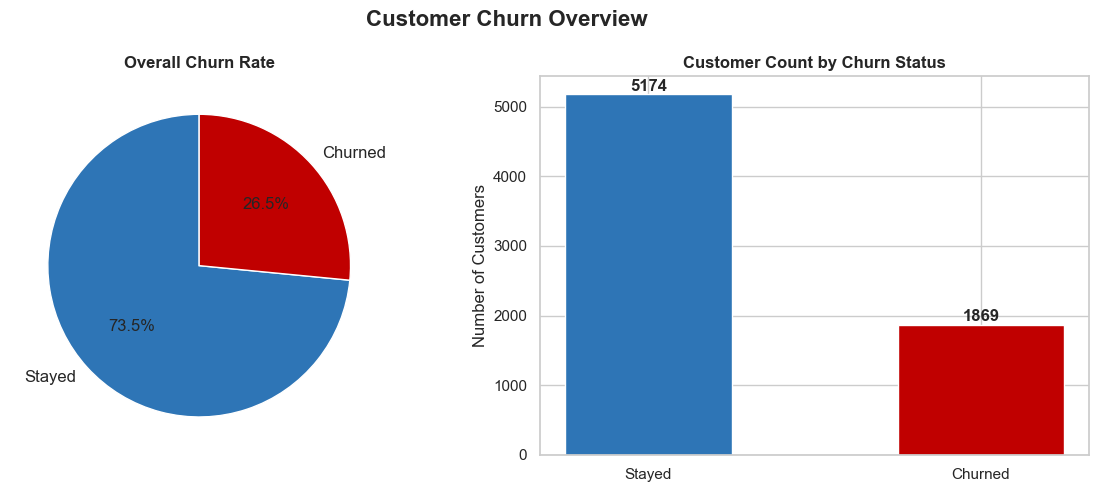

Chart 1 saved!


In [3]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold')

# Pie chart
churn_counts = df['Churn'].value_counts()
colors_pie = ['#2E75B6', '#C00000']
axes[0].pie(churn_counts, labels=['Stayed', 'Churned'],
            autopct='%1.1f%%', colors=colors_pie,
            startangle=90, textprops={'fontsize':12})
axes[0].set_title('Overall Churn Rate', fontweight='bold')

# Bar chart with counts
bars = axes[1].bar(['Stayed', 'Churned'], churn_counts.values,
                   color=colors_pie, width=0.5)
axes[1].set_title('Customer Count by Churn Status', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for bar, count in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50, str(count),
                 ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../output/01_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

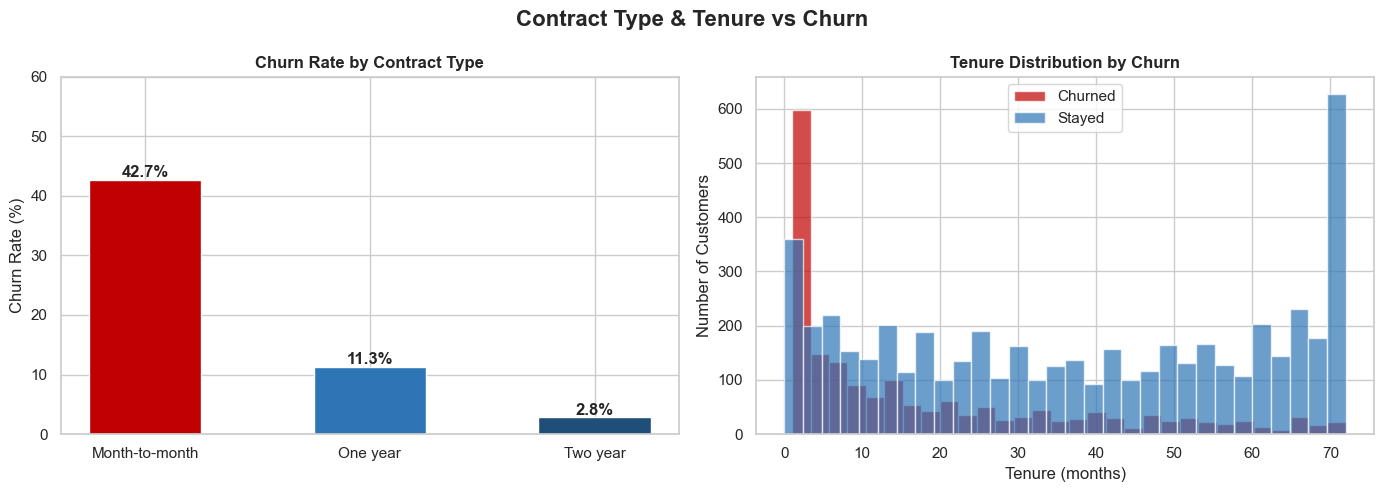

Chart 2 saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Contract Type & Tenure vs Churn', fontsize=16, fontweight='bold')

# Contract type churn rate
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1)
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=['#C00000', '#2E75B6', '#1F4E79'], width=0.5)
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 60)
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f'{val}%',
                 ha='center', fontweight='bold')

# Tenure distribution by churn
df[df['Churn'] == 'Yes']['tenure'].hist(
    ax=axes[1], bins=30, color='#C00000', alpha=0.7, label='Churned')
df[df['Churn'] == 'No']['tenure'].hist(
    ax=axes[1], bins=30, color='#2E75B6', alpha=0.7, label='Stayed')
axes[1].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/02_contract_tenure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

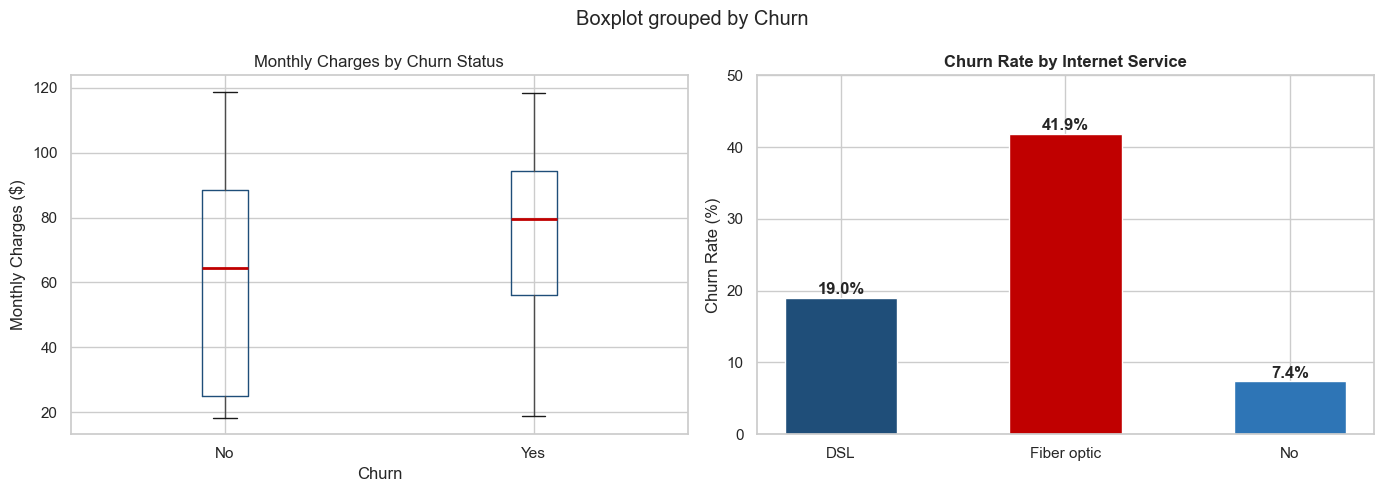

Chart 3 saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Charges vs Churn', fontsize=16, fontweight='bold')

# Monthly charges box plot
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0],
           boxprops=dict(color='#1F4E79'),
           medianprops=dict(color='#C00000', linewidth=2))
axes[0].set_title('Monthly Charges by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')
plt.sca(axes[0])
plt.title('Monthly Charges by Churn Status')

# Internet service churn rate
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1)
bars = axes[1].bar(internet_churn.index, internet_churn.values,
                   color=['#1F4E79', '#C00000', '#2E75B6'], width=0.5)
axes[1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 50)
for bar, val in zip(bars, internet_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f'{val}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/03_charges_internet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

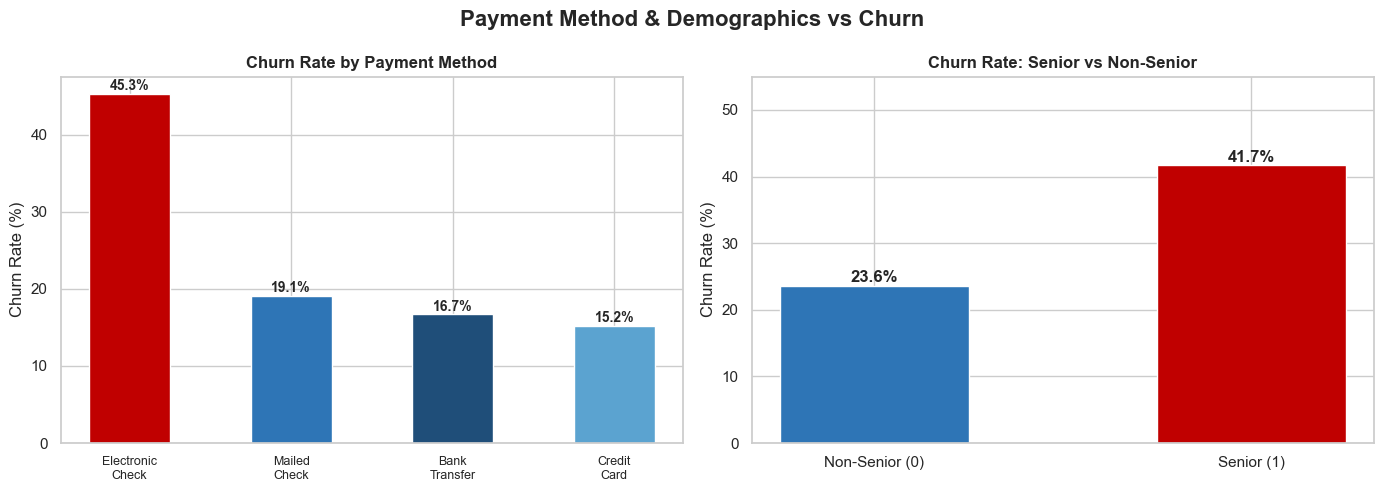

Chart 4 saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Payment Method & Demographics vs Churn', fontsize=16, fontweight='bold')

# Payment method churn rate
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1).sort_values(ascending=False)
short_labels = ['Electronic\nCheck', 'Mailed\nCheck', 'Bank\nTransfer', 'Credit\nCard']
bars = axes[0].bar(range(len(payment_churn)), payment_churn.values,
                   color=['#C00000','#2E75B6','#1F4E79','#5BA3D0'], width=0.5)
axes[0].set_xticks(range(len(payment_churn)))
axes[0].set_xticklabels(short_labels, fontsize=9)
axes[0].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, payment_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f'{val}%',
                 ha='center', fontweight='bold', fontsize=10)

# Senior citizen churn
senior_churn = df.groupby('SeniorCitizen')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1)
axes[1].bar(['Non-Senior (0)', 'Senior (1)'], senior_churn.values,
            color=['#2E75B6', '#C00000'], width=0.5)
axes[1].set_title('Churn Rate: Senior vs Non-Senior', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)
for i, val in enumerate(senior_churn.values):
    axes[1].text(i, val + 0.5, f'{val}%',
                 ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../output/04_payment_senior.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

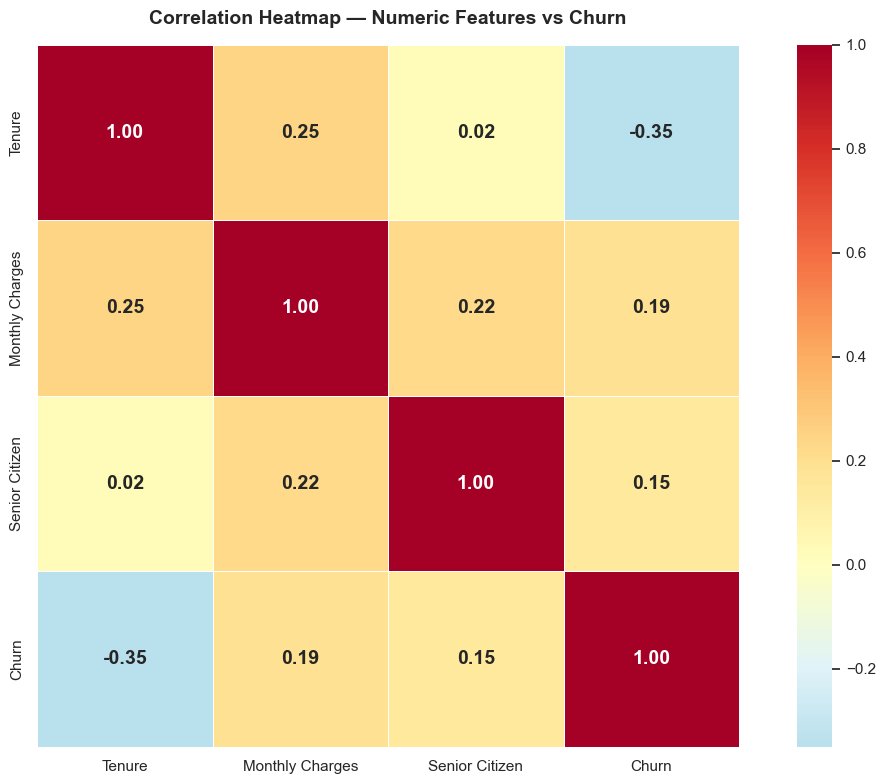

Chart 5 saved!

=== KEY EDA FINDINGS ===
Overall churn rate:          26.5%
Month-to-month churn rate:   42.7%
Two-year contract churn:     2.8%
Fiber optic churn rate:      41.9%
Electronic check churn:      45.3%
Senior citizen churn:        41.7%

TotalCharges dtype issue:    Needs fixing in Stage 3
Class imbalance:             73.5% stayed vs 26.5% churned


In [7]:
# Cell 7 — Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Create numeric version for correlation
df_numeric = df.copy()
df_numeric['Churn_num'] = (df['Churn'] == 'Yes').astype(int)
df_numeric['SeniorCitizen_num'] = df['SeniorCitizen']

# Select key numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen_num', 'Churn_num']
corr_matrix = df_numeric[numeric_cols].corr().round(2)

# Rename for display
corr_matrix.columns = ['Tenure', 'Monthly Charges', 'Senior Citizen', 'Churn']
corr_matrix.index = ['Tenure', 'Monthly Charges', 'Senior Citizen', 'Churn']

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 14, 'weight': 'bold'}, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features vs Churn',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../output/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

# Print summary of findings
print("\n=== KEY EDA FINDINGS ===")
print(f"Overall churn rate:          26.5%")
print(f"Month-to-month churn rate:   42.7%")
print(f"Two-year contract churn:     2.8%")
print(f"Fiber optic churn rate:      41.9%")
print(f"Electronic check churn:      45.3%")
print(f"Senior citizen churn:        41.7%")
print(f"\nTotalCharges dtype issue:    Needs fixing in Stage 3")
print(f"Class imbalance:             73.5% stayed vs 26.5% churned")